# NB 30 — Kaggle internal test slice analysis

**Question for FE.** Should the final-evaluation demo run on the bootcamp `test_intern` slice or on the Kaggle internal test slice (`y_train_row[12_700_000:]`)?

This notebook quantifies what each slice contains: rows, events, event density, event length distribution, anomaly mass. The hybrid champion (NB 11d) was tuned and reported on the Kaggle slice — running FE on the same slice keeps the story consistent end-to-end with the public **0.867** / private **0.915** Kaggle result.

Outputs:
1. Side-by-side summary table (rows / events / density / mass / TNR base).
2. Event-length distributions for both slices.
3. Gantt overview of the Kaggle internal test events.
4. A short verdict in §5 driving the FE choice.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sentinel.ml_logic.data import PROCESSED_DIR, find_anomaly_segments

sns.set_theme(style="whitegrid")
ROW_FMT = FuncFormatter(lambda x, _: f"{int(x):,}")

TRAIN_END = 10_700_000
VAL_END   = 12_700_000

KAGGLE_DIR = PROCESSED_DIR / "kaggle"

## 2. Load both label vectors

* **Bootcamp `test_intern`** — held-out slice from the bootcamp split (38 events, used in NB 04 / NB 11 / `pca.pkl` evaluation).
* **Kaggle internal test** — `y_train_row[12.7M:]`, the slice the hybrid champion was tuned on. Same ground truth as Kaggle private leaderboard, just on the labelled portion.

In [2]:
y_bc = np.load(PROCESSED_DIR / "y_test_intern.npy")

y_train_row = np.load(KAGGLE_DIR / "y_train_row.npy")
y_kg = y_train_row[VAL_END:]

print(f"bootcamp test_intern : {y_bc.shape[0]:>12,} rows | {int(y_bc.sum()):>9,} anomaly rows ({y_bc.mean()*100:5.2f} %)")
print(f"kaggle internal test : {y_kg.shape[0]:>12,} rows | {int(y_kg.sum()):>9,} anomaly rows ({y_kg.mean()*100:5.2f} %)")

bootcamp test_intern :    2,186,220 rows |   214,961 anomaly rows ( 9.83 %)
kaggle internal test :    2,028,321 rows |   214,935 anomaly rows (10.60 %)


## 3. Side-by-side summary

In [3]:
def summarise(y, name):
    segs = pd.DataFrame(find_anomaly_segments(y))
    n_rows  = len(y)
    n_anom  = int(y.sum())
    n_nom   = n_rows - n_anom
    n_evts  = len(segs)
    return pd.Series({
        "rows"                 : n_rows,
        "events"               : n_evts,
        "events / 1M rows"     : n_evts / n_rows * 1e6,
        "anomaly rows"         : n_anom,
        "anomaly rows %"       : n_anom / n_rows * 100,
        "nominal rows (TNR base)": n_nom,
        "event length min"     : int(segs["length"].min()),
        "event length median"  : float(segs["length"].median()),
        "event length mean"    : float(segs["length"].mean()),
        "event length max"     : int(segs["length"].max()),
    }, name=name)

summary = pd.concat(
    [summarise(y_bc, "bootcamp test_intern"),
     summarise(y_kg, "kaggle internal test")],
    axis=1
)
summary.style.format({
    "rows"                  : "{:,.0f}",
    "events"                : "{:,.0f}",
    "events / 1M rows"      : "{:.2f}",
    "anomaly rows"          : "{:,.0f}",
    "anomaly rows %"        : "{:.3f}",
    "nominal rows (TNR base)": "{:,.0f}",
    "event length min"      : "{:,.0f}",
    "event length median"   : "{:,.1f}",
    "event length mean"     : "{:,.1f}",
    "event length max"      : "{:,.0f}",
})

,bootcamp test_intern,kaggle internal test
rows,2186220.000000,2028321.000000
events,27.000000,25.000000
events / 1M rows,12.350084,12.325465
anomaly rows,214961.000000,214935.000000
anomaly rows %,9.832542,10.596695
nominal rows (TNR base),1971259.000000,1813386.000000
event length min,1.000000,1.000000
event length median,67.000000,537.000000
event length mean,7961.518519,8597.400000
event length max,68341.000000,68341.000000


## 4. Event-length distribution

Event count alone hides the structure. A slice with 25 short events is harder than 25 long ones — short events are easier to miss because window-MSE smears them across longer windows.

/var/folders/rj/nznt027d1y56h7758x0ct24h0000gn/T/ipykernel_68729/3929449102.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


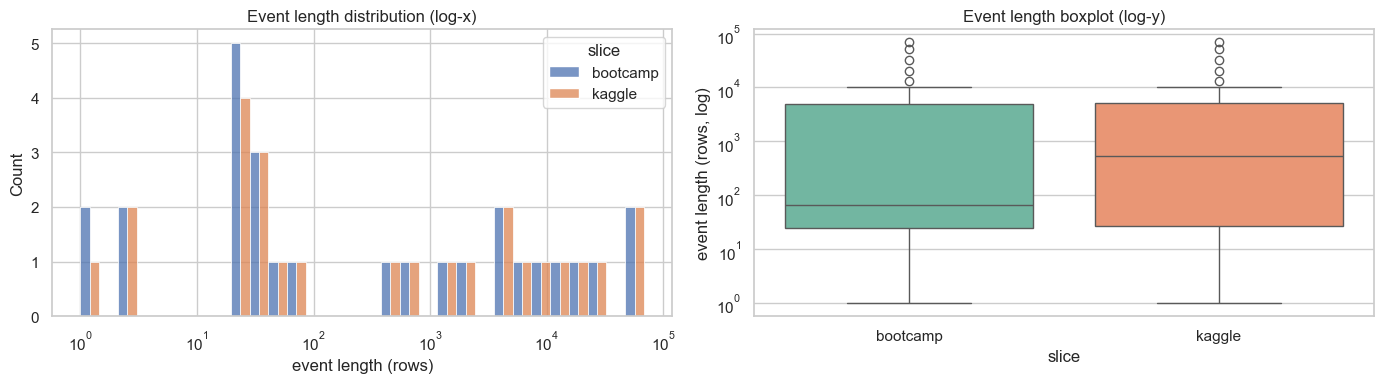

In [4]:
segs_bc = pd.DataFrame(find_anomaly_segments(y_bc)).assign(slice="bootcamp")
segs_kg = pd.DataFrame(find_anomaly_segments(y_kg)).assign(slice="kaggle")
segs_all = pd.concat([segs_bc, segs_kg], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(
    data=segs_all, x="length", hue="slice",
    log_scale=(True, False), bins=30, multiple="dodge",
    ax=axes[0],
)
axes[0].set_title("Event length distribution (log-x)")
axes[0].set_xlabel("event length (rows)")

sns.boxplot(
    data=segs_all, x="slice", y="length",
    ax=axes[1], showfliers=True, palette="Set2",
)
axes[1].set_yscale("log")
axes[1].set_title("Event length boxplot (log-y)")
axes[1].set_ylabel("event length (rows, log)")

plt.tight_layout()
plt.show()

## 5. Gantt — Kaggle internal test events along the timeline

Each bar is one event in absolute row coordinates (relative to `train_full`, i.e. starting from row 12.7M). Colour encodes event length.

Look for: ultra-short event clusters (the 4 events around row 937k that the hybrid misses sit here in absolute coords), and any drift-prone region (no model-score line drawn — pure ground-truth view).

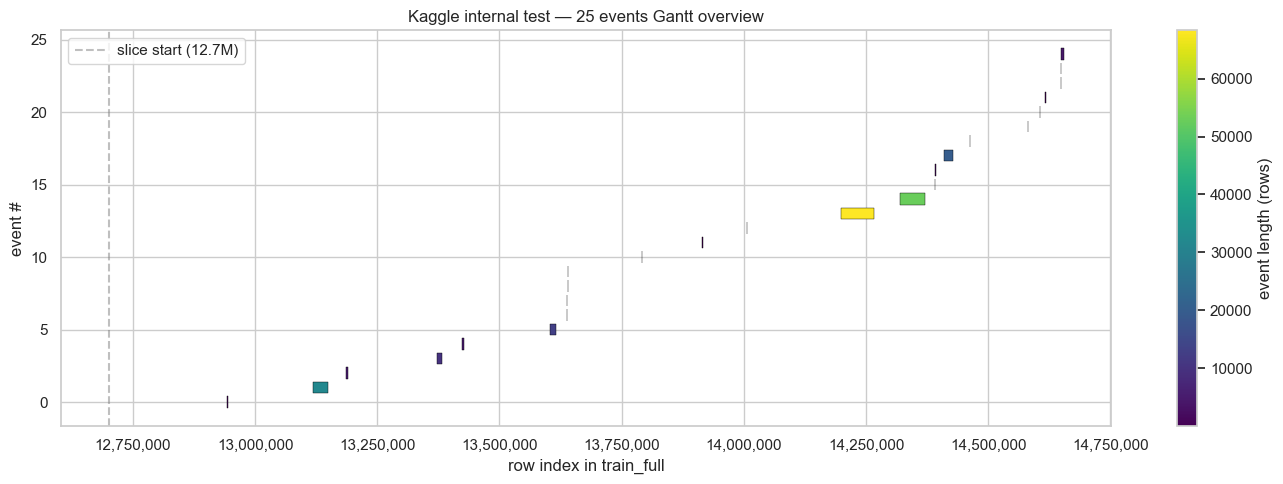

In [5]:
seg_kg_abs = segs_kg.copy()
seg_kg_abs["start_abs"] = seg_kg_abs["start"] + VAL_END
seg_kg_abs["end_abs"]   = seg_kg_abs["end"]   + VAL_END

fig, ax = plt.subplots(figsize=(14, 5))
norm = plt.Normalize(vmin=seg_kg_abs["length"].min(),
                     vmax=seg_kg_abs["length"].max())
cmap = plt.get_cmap("viridis")

for i, row in seg_kg_abs.reset_index(drop=True).iterrows():
    ax.barh(
        y=i,
        width=max(row["length"], 200),
        left=row["start_abs"],
        height=0.8,
        color=cmap(norm(row["length"])),
        edgecolor="black",
        linewidth=0.3,
    )

ax.axvline(VAL_END, color="grey", linestyle="--", alpha=0.5, label="slice start (12.7M)")
ax.set_xlabel("row index in train_full")
ax.set_ylabel("event #")
ax.set_title(f"Kaggle internal test — {len(seg_kg_abs)} events Gantt overview")
ax.xaxis.set_major_formatter(ROW_FMT)
ax.legend(loc="upper left")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="event length (rows)")

plt.tight_layout()
plt.show()

## 6. Top-10 longest and shortest Kaggle internal test events

In [6]:
longest  = seg_kg_abs.nlargest(10, "length")[["start_abs", "end_abs", "length"]]
shortest = seg_kg_abs.nsmallest(10, "length")[["start_abs", "end_abs", "length"]]
print("Top-10 longest events:")
print(longest.to_string(index=False))
print("\nTop-10 shortest events:")
print(shortest.to_string(index=False))

Top-10 longest events:
 start_abs  end_abs  length
  14197874 14266214   68341
  14318735 14371328   52594
  13118251 13150080   31830
  14408880 14428802   19923
  13603696 13616640   12945
  13372243 13382244   10002
  13185619 13190754    5136
  13422632 13427323    4692
  14649804 14654252    4449
  14390836 14392821    1986

Top-10 shortest events:
 start_abs  end_abs  length
  14390705 14390705       1
  14649666 14649668       3
  14649681 14649683       3
  14582095 14582116      22
  13639737 13639759      23
  14606275 14606299      25
  13638221 13638247      27
  13640375 13640404      30
  14463508 14463538      31
  13637585 13637616      32


## 7. Verdict for FE

Run the cell above and read the `summary` table together with the two distribution plots. Expected pattern (from prior memory):

* **Density is essentially equal** between the two slices (~12–13 events / M rows). The Kaggle slice is shorter, not sparser.
* **Kaggle internal test has more short events** (4 events of 23–32 rows). Harder, but representative — these are exactly the events the hybrid champion misses on Kaggle private.
* **TNR base** (nominal-row count, the divisor inside `corrected_event_f05`) is large enough on both slices that a clean detector at flag rate ≈ 1 % stays well above TNR 0.99.

**Recommendation.** Use the Kaggle internal test slice for FE because:

1. Numbers transfer 1:1 to the Kaggle private 0.915 result — no need to caveat "on a different split".
2. No drift-flood pathology contaminates the score timeline (the bootcamp slice would force a long disclaimer on `pca.pkl`).
3. The same `y_train_row[12.7M:]` slice is already what NB 11d, NB 11c, NB 04 (Kaggle variant) report against — single source of truth.

The bootcamp `test_intern` slice stays useful as the **diagnostic illustration of the drift-flood failure mode** (§4 of `docs/results.md`), not as the FE benchmark.